Assignment 1 CV

In [1]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import cv2

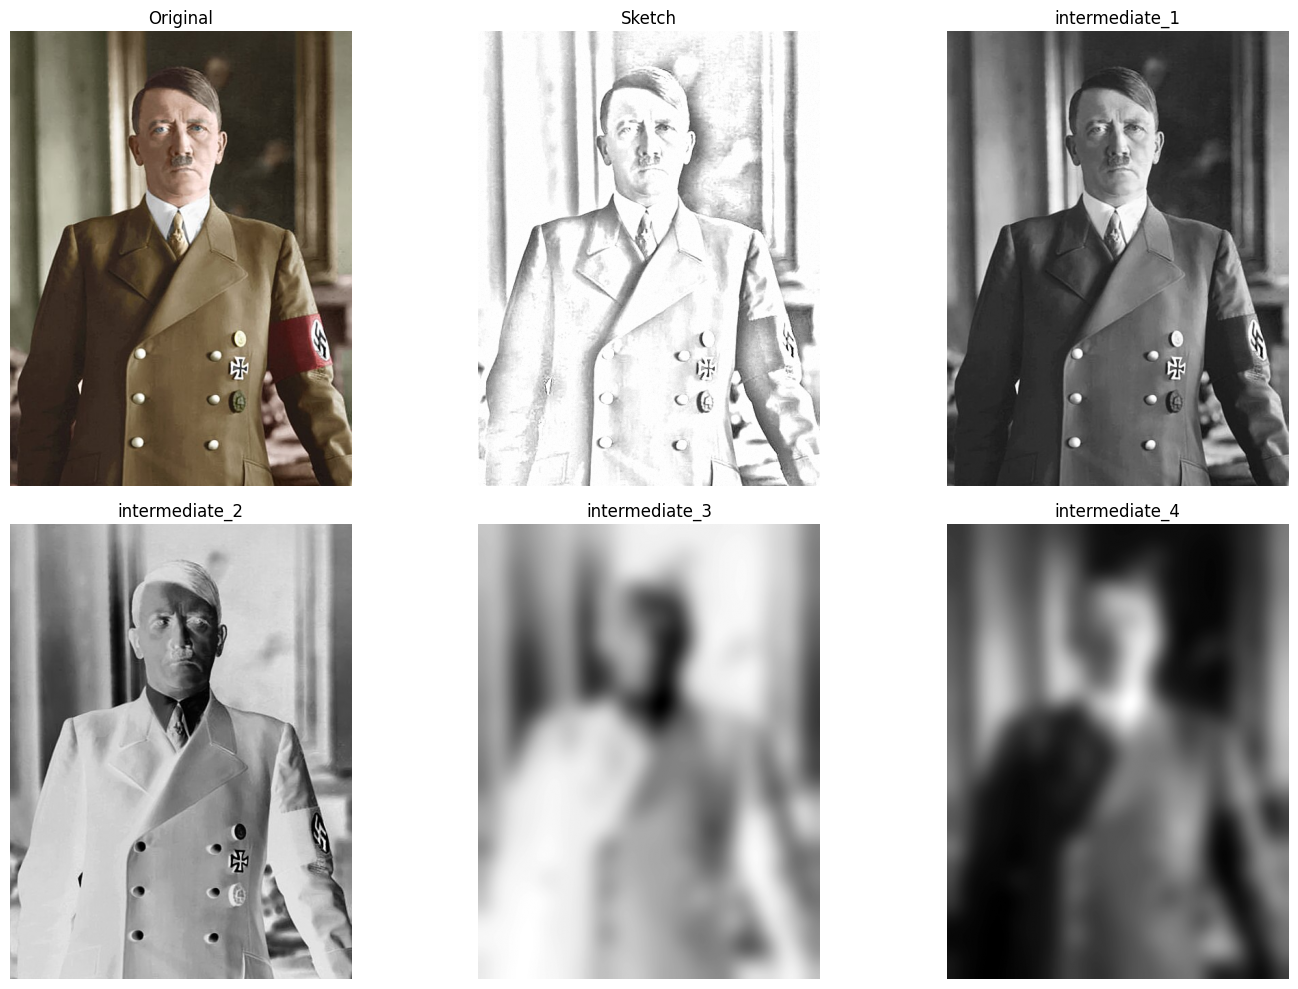

In [ ]:
def pencil_sketch(image_path, blur_kernel=99 ,noise_std = 5):
    """
    Convert an image to pencil sketch effect.
    
    Args:
        image_path (str): Path to input image
        blur_kernel (int): Gaussian blur kernel size (must be odd)
    
    Returns:
        tuple: (original_rgb, sketch) or (None, None) if error
    """
    # TODO: Implement the algorithm
    # Step 1: Load image
    
    # Step 2: Convert to grayscale
    
    # Step 3: Invert grayscale
    
    # Step 4: Apply Gaussian blur
    
    # Step 5: Invert blurred image
    
    # Step 6: Divide and scale
    image = cv2.imread(image_path)

    gray = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
    inv_gray = 255 - gray

    blur_inv_gray = cv2.GaussianBlur(inv_gray,(blur_kernel,blur_kernel),0)
    inv_blur_inv_gray = 255 - blur_inv_gray

    dodge = (gray/(inv_blur_inv_gray + 1e-6))*256
    sketch = np.clip(dodge,0,255).astype(np.uint8)

    noise = np.random.normal(0, noise_std, sketch.shape).astype(np.int16)
    sketch = np.clip(sketch.astype(np.int16) + noise, 0, 255).astype(np.uint8)
    
    return image, sketch,(gray,inv_gray,blur_inv_gray,inv_blur_inv_gray)


def display_result(original, sketch, others = None, save_path=None):
    """
    Display original and sketch side-by-side.
    
    Args:
        original: Original image (RGB)
        sketch: Sketch image (grayscale)
        save_path: Optional path to save the sketch
    """
    # TODO: Create matplotlib figure with 1 row, 2 columns
    # Display original on left, sketch on right
    # Add titles and remove axes
    # If save_path provided, save the sketch
    original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

    images = [original,sketch]
    titles = ['Original','Sketch']

    count = 0
    len_others=0
    if others is not None :
        len_others = len(others)
        for i in others :
            images.append(i)
            count += 1
            titles.append('intermediate_{}'.format(count))

    ids = list(range(len_others+2))

    fig, axes = plt.subplots(2,3,figsize = (15,10))
    axes = axes.ravel()

    for a,b,c in zip(images,titles,ids) :
        if c == 0 :
            axes[c].imshow(a)
        else :
            axes[c].imshow(a,cmap = 'gray')
        
        axes[c].set_title(b)
        axes[c].axis('off')
    
    plt.tight_layout()
    plt.show()


def main():
    """Main function to run the pencil sketch converter."""
    # TODO: Get image path from user or command line
    # Call pencil_sketch function
    # Call display_result function
    # Handle any errors

    image_path = input('Enter image path')
    blur_parameter = int(input("Enter blur parameter"))
    image , sketch,others = pencil_sketch(image_path,blur_parameter)

    display_result(image,sketch,others)


if __name__ == '__main__':
    main()

Modified Pencil Sketch


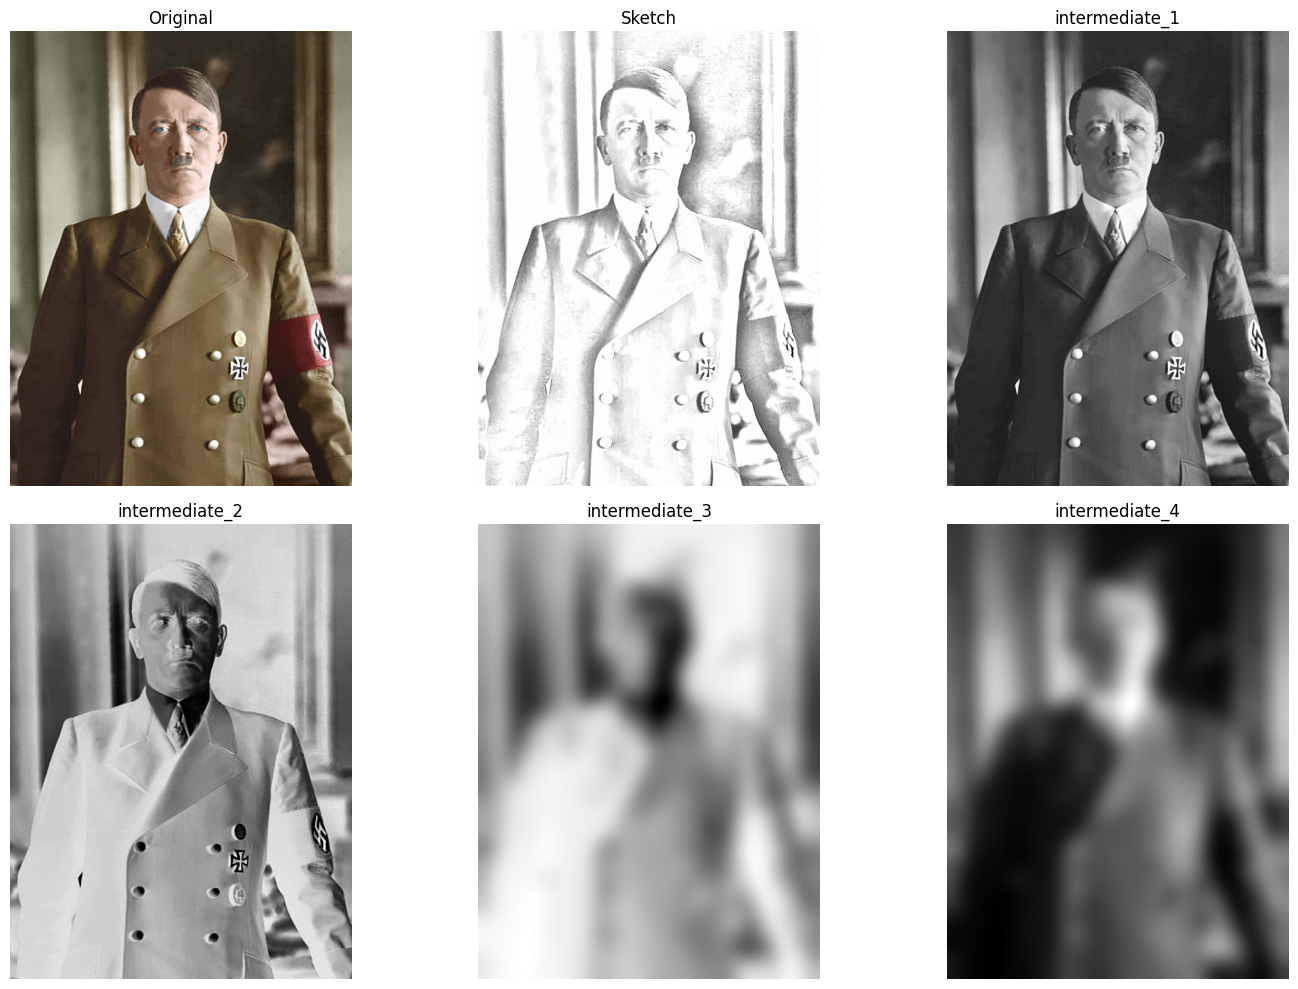

In [ ]:
def pencil_sketch(image_path, blur_kernel=21):
    """
    Convert an image to pencil sketch effect.
    
    Args:
        image_path (str): Path to input image
        blur_kernel (int): Gaussian blur kernel size (must be odd)
    
    Returns:
        tuple: (original_rgb, sketch) or (None, None) if error
    """
    # TODO: Implement the algorithm
    # Step 1: Load image
    
    # Step 2: Convert to grayscale
    
    # Step 3: Invert grayscale
    
    # Step 4: Apply Gaussian blur
    
    # Step 5: Invert blurred image
    
    # Step 6: Divide and scale
    image = cv2.imread(image_path)

    gray = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
    inv_gray = 255 - gray

    blur_inv_gray = cv2.GaussianBlur(inv_gray.astype(np.float32)/255.0,(blur_kernel,blur_kernel),0)
    inv_blur_inv_gray = 1.0 - blur_inv_gray

    dodge = ((gray/255)/(inv_blur_inv_gray + 1e-6))

    gamma = 0.9   # < 1 brightens mid-tones
    sketch = np.power(np.clip(dodge, 0, 1), gamma)
    sketch = (sketch * 255).astype(np.uint8)

    noise = np.random.normal(0, 4, sketch.shape).astype(np.int16)
    sketch = np.clip(sketch.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    
    return image, sketch,(gray,inv_gray,blur_inv_gray,inv_blur_inv_gray)


def display_result(original, sketch, others = None, save_path=None):
    """
    Display original and sketch side-by-side.
    
    Args:
        original: Original image (RGB)
        sketch: Sketch image (grayscale)
        save_path: Optional path to save the sketch
    """
    # TODO: Create matplotlib figure with 1 row, 2 columns
    # Display original on left, sketch on right
    # Add titles and remove axes
    # If save_path provided, save the sketch
    original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    if sketch.ndim != 2 :
        sketch = cv2.cvtColor(sketch,cv2.COLOR_BGR2RGB)

    images = [original,sketch]
    titles = ['Original','Sketch']

    count = 0
    len_others=0
    if others is not None :
        len_others = len(others)
        for i in others :
            images.append(i)
            count += 1
            titles.append('intermediate_{}'.format(count))

    ids = list(range(len_others+2))

    fig, axes = plt.subplots(2,3,figsize = (15,10))
    axes = axes.ravel()

    for a,b,c in zip(images,titles,ids) :
        if c == 0 :
            axes[c].imshow(a)
        else :
            axes[c].imshow(a,cmap = 'gray')
        
        axes[c].set_title(b)
        axes[c].axis('off')
    
    plt.tight_layout()
    plt.show()


def main():
    """Main function to run the pencil sketch converter."""
    # TODO: Get image path from user or command line
    # Call pencil_sketch function
    # Call display_result function
    # Handle any errors

    image_path = input('Enter image path')
    blur_parameter = int(input("Enter blur parameter"))
    image , sketch,others = pencil_sketch(image_path,blur_parameter)

    display_result(image,sketch,others)


if __name__ == '__main__':
    main()

Color Sketch Effect

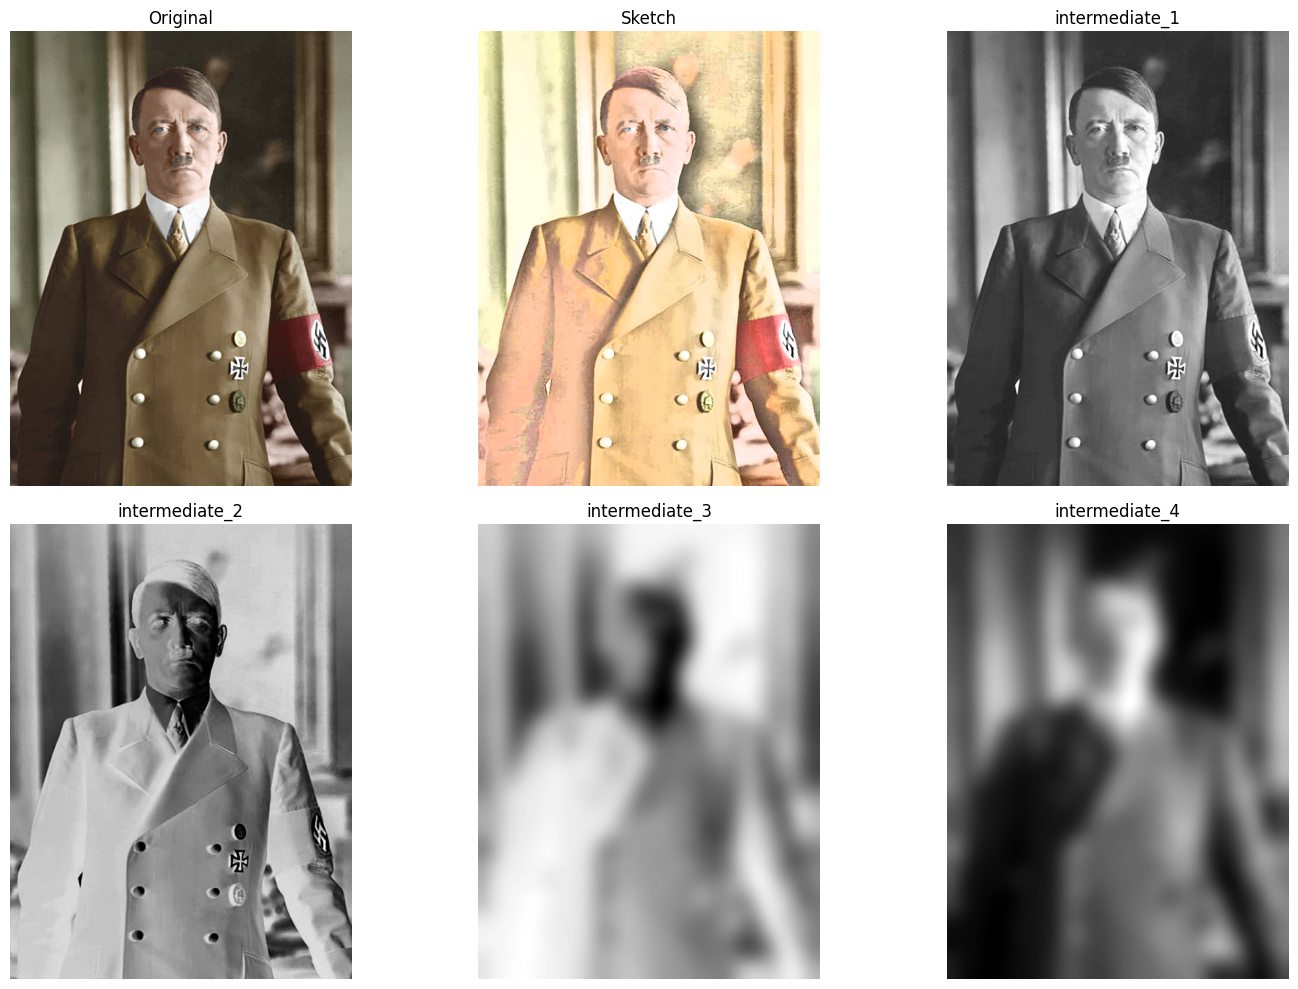

In [ ]:
def color_sketch(image_path,saturation_factor = 0.6,blur_kernel = 99,noise_std = 5) :

    image = cv2.imread(image_path)
    image_hsv = cv2.cvtColor(image,cv2.COLOR_BGR2HSV)
    hue,sat,val = cv2.split(image_hsv)

    inv_gray = 255 - val
    blur_inv_gray = cv2.GaussianBlur(inv_gray,(blur_kernel,blur_kernel),0)
    inv_blur_inv_gray = 255 - blur_inv_gray

    dodge = (val/(inv_blur_inv_gray + 1e-6))*256
    sketch_val = np.clip(dodge,0,255).astype(np.uint8)

    noise = np.random.normal(0,noise_std,sketch_val.shape)
    sketch_val = np.clip(sketch_val + noise,0,255).astype(np.uint8)

    final_sat = np.clip(sat.astype(np.float32) * saturation_factor,0, 255).astype(np.uint8)

    final_image_hsv = cv2.merge([hue,final_sat.astype(np.uint8),sketch_val])
    final_image = cv2.cvtColor(final_image_hsv,cv2.COLOR_HSV2BGR)

    return image, final_image,(val,inv_gray,blur_inv_gray,inv_blur_inv_gray)


def main_color():
    """Main function to run the pencil sketch converter."""
    # TODO: Get image path from user or command line
    # Call pencil_sketch function
    # Call display_result function
    # Handle any errors

    image_path = input('Enter image path')
    blur_parameter = int(input("Enter blur parameter"))
    saturation_factor = float(input("Enter saturation parameter"))
    image , sketch,others = color_sketch(image_path,saturation_factor,blur_parameter)

    display_result(image,sketch,others)


if __name__ == '__main__':
    main_color()

    


Modified code llm

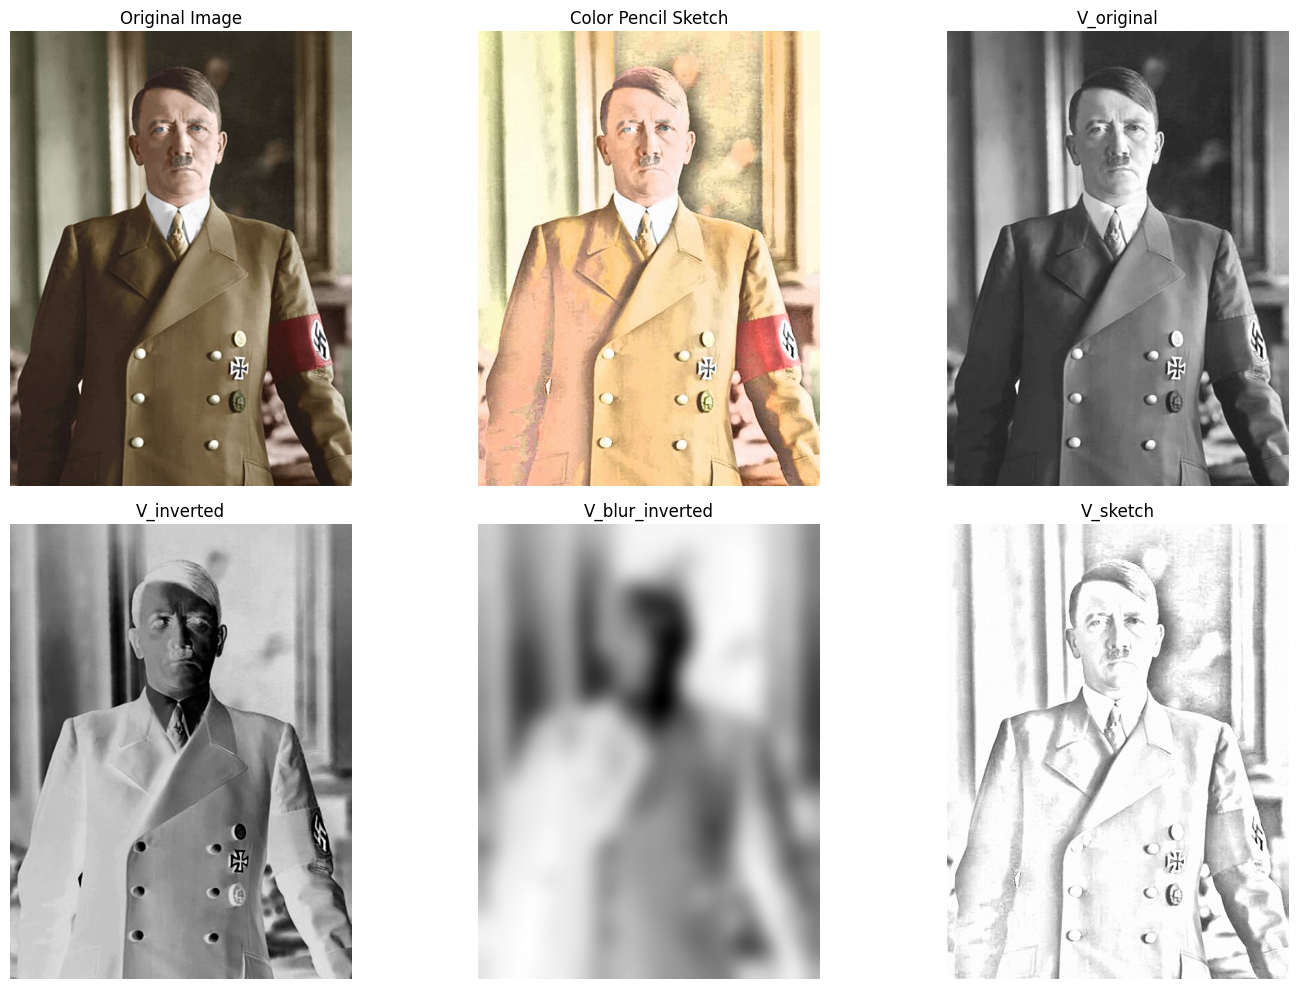

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


def color_pencil_sketch(
    image_path,
    blur_kernel=21,
    saturation_factor=0.6,
    gamma=0.9,
    noise_sigma=4,
    edge_strength_factor=0.15
):
    """
    Generate a perceptually accurate color pencil sketch.

    Args:
        image_path (str): Path to input image
        blur_kernel (int): Gaussian blur kernel (odd)
        saturation_factor (float): Global saturation reduction
        gamma (float): Gamma correction for tone compression
        noise_sigma (float): Paper grain strength
        edge_strength_factor (float): Edge pressure intensity

    Returns:
        original_bgr, final_bgr, debug_dict
    """

    # ----------------------------
    # 1. Load image
    # ----------------------------
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError("Image not found or invalid path")

    # ----------------------------
    # 2. Convert to HSV
    # ----------------------------
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    H, S, V = cv2.split(hsv)

    # ----------------------------
    # 3. Normalize Value channel
    # ----------------------------
    V_f = V.astype(np.float32) / 255.0

    # ----------------------------
    # 4. Pencil sketch (dodge blend)
    # ----------------------------
    inv_V = 1.0 - V_f
    blur_inv_V = cv2.GaussianBlur(inv_V, (blur_kernel, blur_kernel), 0)
    inv_blur = 1.0 - blur_inv_V

    dodge = V_f / (inv_blur + 1e-6)
    dodge = np.clip(dodge, 0, 1)

    # ----------------------------
    # 5. Gamma correction (human perception)
    # ----------------------------
    sketch_V = np.power(dodge, gamma)

    # ----------------------------
    # 6. Paper texture (grain)
    # ----------------------------
    noise = np.random.normal(0, noise_sigma / 255.0, sketch_V.shape)
    sketch_V = np.clip(sketch_V + noise, 0, 1)

    # ----------------------------
    # 7. Edge-weighted pressure variation
    # ----------------------------
    gx = cv2.Sobel(V_f, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(V_f, cv2.CV_32F, 0, 1, ksize=3)
    edge_mag = cv2.magnitude(gx, gy)
    edge_mag = cv2.normalize(edge_mag, None, 0, 1, cv2.NORM_MINMAX)

    sketch_V *= (1 - edge_strength_factor * edge_mag)
    sketch_V = np.clip(sketch_V, 0, 1)

    # Convert back to uint8
    sketch_V_u8 = (sketch_V * 255).astype(np.uint8)

    # ----------------------------
    # 8. Adaptive saturation (colored pencil realism)
    # ----------------------------
    S_f = S.astype(np.float32) / 255.0
    adaptive_S = S_f * (0.5 + 0.5 * sketch_V)
    adaptive_S *= saturation_factor
    adaptive_S = np.clip(adaptive_S, 0, 1)
    adaptive_S_u8 = (adaptive_S * 255).astype(np.uint8)

    # ----------------------------
    # 9. Merge HSV and convert back
    # ----------------------------
    final_hsv = cv2.merge([H, adaptive_S_u8, sketch_V_u8])
    final_bgr = cv2.cvtColor(final_hsv, cv2.COLOR_HSV2BGR)

    debug = {
        "V_original": V,
        "V_inverted": (inv_V * 255).astype(np.uint8),
        "V_blur_inverted": (blur_inv_V * 255).astype(np.uint8),
        "V_sketch": sketch_V_u8,
        "edge_map": (edge_mag * 255).astype(np.uint8),
    }

    return image, final_bgr, debug


def display_results(original, sketch, debug_dict=None):
    """
    Display original, sketch, and optional debug stages.
    """

    images = [cv2.cvtColor(original, cv2.COLOR_BGR2RGB),
              cv2.cvtColor(sketch, cv2.COLOR_BGR2RGB)]
    titles = ["Original Image", "Color Pencil Sketch"]

    if debug_dict:
        for k, v in debug_dict.items():
            images.append(v if v.ndim == 2 else cv2.cvtColor(v, cv2.COLOR_BGR2RGB))
            titles.append(k)

    cols = 3
    rows = int(np.ceil(len(images) / cols))

    plt.figure(figsize=(15, 5 * rows))
    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img, cmap="gray" if img.ndim == 2 else None)
        plt.title(title)
        plt.axis("off")
    plt.tight_layout()
    plt.show()


def main():
    image_path = input("Enter image path: ").strip()
    blur_kernel = int(input("Blur kernel (odd, e.g. 21): "))
    saturation_factor = float(input("Saturation factor (0.4–0.7): "))

    original, sketch, debug = color_pencil_sketch(
        image_path=image_path,
        blur_kernel=blur_kernel,
        saturation_factor=saturation_factor
    )

    display_results(original, sketch, debug)


if __name__ == "__main__":
    main()


Video processing


In [38]:
input_path = input("Enter video file path")
output_path = './test_sketch2.mp4'


def pencil_sketch_frame(frame) :

    gray = cv2.cvtColor(frame,cv2.COLOR_BGR2GRAY)
    inv_gray = 255 - gray

    blur_kernel = 25
    blur_inv_gray = cv2.GaussianBlur(inv_gray,(blur_kernel,blur_kernel),0)
    inv_blur_inv_gray = 255 - blur_inv_gray

    dodge = (gray/(inv_blur_inv_gray + 1e-6))*256
    sketch = np.clip(dodge,0,255).astype(np.uint8)

    return sketch

cap = cv2.VideoCapture(input_path)

fps = cap.get(cv2.CAP_PROP_FPS)
w   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
n   = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(output_path, fourcc, fps, (w, h))

for i in range(n):
    ret, frame = cap.read()
    if not ret:
        break

    sketch = pencil_sketch_frame(frame)   # grayscale
    sketch = cv2.cvtColor(sketch, cv2.COLOR_GRAY2BGR)

    out.write(sketch)

    print(f"\rProcessing: {int((i+1)/n*100)}%", end="")

cap.release()
out.release()


Processing: 100%

Live Video Processing

In [12]:
def pencil_sketch_frame_live(frame):

    gray = cv2.cvtColor(frame,cv2.COLOR_BGR2GRAY)
    inv_gray = 255 - gray

    blur_kernel = 99
    blur_inv_gray = cv2.GaussianBlur(inv_gray,(blur_kernel,blur_kernel),0)
    inv_blur_inv_gray = 255 - blur_inv_gray

    dodge = (gray/(inv_blur_inv_gray + 1e-6))*256
    sketch_gray = np.clip(dodge,0,255).astype(np.uint8)
    sketch = cv2.cvtColor(sketch_gray,cv2.COLOR_GRAY2BGR)

    return sketch

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    raise RuntimeError("Camera not accessible")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    sketch = pencil_sketch_frame_live(frame)

    cv2.imshow("Original", frame)
    cv2.imshow("Pencil Sketch", sketch)

    if cv2.waitKey(1) == 27:   # ESC
        break

cap.release()
cv2.destroyAllWindows()
